This notebook shows the implementation of a logistic regression model in Numpy. A linear and a polynomial regression model are trained and compared with the Scikit-learn implementation via the learned parameters of the model and a quick evaluation on model accuracy.

In this notebook:
1. **Implementation of Logistic Regression in Numpy**
2. **Linear Logistic Regression**
3. **Polynomial Logistic Regression**

Output:
1. Prediction Array of Linear Logistic Regression for Test Set
2. Prediction Array of Polynomial Logistic Regression for Test Set

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utilities_notebook import zscore_normalize_features, apply_zscore_normalization

pd.options.display.float_format = '{:0.4f}'.format
np.set_printoptions(precision=4, suppress=True)

In [59]:
X_train = pd.read_csv("../data/linear/X_train.csv", index_col=0, parse_dates=True)
y_train = pd.read_csv("../data/linear/y_train.csv", index_col=0, parse_dates=True)
X_test = pd.read_csv("../data/linear/X_test.csv", index_col=0, parse_dates=True)
y_test = pd.read_csv("../data/linear/y_test.csv", index_col=0, parse_dates=True)

print(f"Shape\n"
      f"X_train: {X_train.shape}, y_train: {y_train.shape}\n"
      f"X_test:  {X_test.shape}, y_test : {y_test.shape}\n")

X_train.head()

Shape
X_train: (567, 6), y_train: (567, 1)
X_test:  (144, 6), y_test : (144, 1)



,volume,pct_change_1d,rsi,adx,corr,volatility
Date,,,,,,
2023-02-02,8523200,-0.0263,25.7175,20.0382,0.6622,1.5033
2023-02-03,9219400,0.0270,39.1584,23.3034,0.7018,1.8069
2023-02-07,11662300,-0.0368,30.5575,27.4842,0.8373,2.0947
2023-02-08,5665300,0.0109,35.0839,31.2470,0.8722,2.1606
2023-02-09,6074700,0.0054,37.3526,33.7872,0.8379,2.1827


## 1 Implementation of Logistic Regression in Numpy

- Methodology
- Logistic regression model
- Cost function
- Learning algorithm

**Credit**: I started this project after going through the first part of Andrew Ng's machine learning specialization: Supervised Machine Learning. Hence, all credit goes to Andrew Ng and his team. I wrote these functions myself from scratch to make sure I understood it.

Initially I had written them with Pandas but ultimately found Numpy easier to work with when manipulating and moving data around. My implementation is the same as Andrew Ng's except that I had used vectorization for calculations and some minor adjustments.
___

#### Methodology:  
1) Compute the cost function
2) Compute the gradient for gradient descent updates
3) Perform batch gradient descent to learn the best fit parameters
4) Make a prediction on a sample based on learned parameters

#### The Logistic Regression Model:

$$f_{\mathbf{w},b}(\mathbf{x^{(i)}}) = g(\mathbf{x^{(i)}} \cdot \mathbf{w} + b)$$

where

* $\mathbf{x}$ is the input feature matrix of dimensions $m \times n$
* $\mathbf{w}$ is the vector of weight parameters of length $n$
* $b$ is the bias parameter
* $\mathbf{x^{(i)}}$ is the $i^{th}$ input feature vector with length $n$
* $\mathbf{x^{(i)}} \cdot \mathbf{w}$ is the dot product between vector $\mathbf{x^{(i)}}$ and $\mathbf{w}$
* $g$ is the sigmoid function

The sigmoid function $g$ outputs a value $f_{w,b}(x^{(i)})$ where $-1<f_{w,b}(x^{(i)})<1$ which can be interpreted as the probability of the sample $i$ being a positive class $1$ or negative class $0$ based on a threshold value $p$.

The sigmoid function is defined as
$$g(z) = \frac{1}{1+e^{-z}}$$

In [60]:
# sigmoid function

def sigmoid(X):
    X = np.clip(X, -500, 500) # protect against overflow
    return 1/(1+np.exp(-X))

#### Cost function

In order to find the best fit parameters $\mathbf{w}$ and $b$ for the model, a cost function $J(w,b)$ has to be defined which is a metric that tells us how well a model fits to the data.

$$
J(\mathbf{w},b) = \frac{1}{m}\sum_{i=0}^{m-1}[loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)},y^{(i)}))]
+ \frac{\lambda}{2m} \sum_{j=0}^{n-1}w_j^2
$$

where $loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)},y^{(i)}))$ is the logistic loss function or Binary Cross-Entropy loss function for a single data point.

$$
loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)},y^{(i)})) =
\begin{cases}
-\log(f_{\mathbf{w},b}(\mathbf{x^{(i)}})) & \text{if } y^{(i)} = 1 \\ 
-\log(1 - f_{\mathbf{w},b}(\mathbf{x^{(i)}})) & \text{if } y^{(i)} = 0
\end{cases}
$$

and $ \frac{\lambda}{2m} \sum_{j=0}^{n-1}w_j^2 $ is the regularization term.

* $f_{\mathbf{w},b}(\mathbf{x}^{(i)}) \in (-1,1)$ is the model's prediction for the $i^{th}$ example
* $y^{(i)}$ is the target value for the $i^{th}$ example
* $m$ is the number of training examples
* $n$ is the number of weight parameters
* $\lambda$ is the regularization hyperparameter

The Binary Cross-Entropy loss function is a convex function which has the property of having a global minimum, which is a single minimum cost.

In [61]:
# compute cost function

def compute_cost(X, y, w, b, lambda_=0):
    """
    Computes cost

    Args:
        X (ndarray (m,n)) : Data, m examples with n features
        y (ndarray (m,))  : target values
        w (ndarray (n,))  : model parameters
        b (scalar)        : model parameter
    
    Returns:
        cost (scalar)     : cost
    """
    m = X.shape[0]
    z = X @ w + b
    f_wb = sigmoid(z)
    
    # Clip f_wb to be between a tiny epsilon and 1-epsilon
    epsilon = 1e-15
    f_wb = np.clip(f_wb, epsilon, 1 - epsilon)
    
    loss = -y * np.log(f_wb) - (1-y) * np.log(1-f_wb)
    regularized_cost = lambda_ / (2*m) * np.sum(w**2)

    return np.sum(loss) / m + regularized_cost

#### Learning algorithm

Then it follows logically that the best fit parameters $w$ and $b$ would be the model with the least possible value of $J(w,b)$.

Fortunately, this can be done via a learning algorithm called Gradient Descent.

Gradient descent is an algorithm that updates a model's parameters in the direction of steepest descent which we use to iteratively minimize the cost function.

At each iteration, the weight parameter $w_j$ and bias b is updated via

$$
\begin{aligned}
&\text{repeat until convergence: }\{ \\
    &w_j = w_j - \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j} && \text{for } j = 0, ..., n-1 \\
    &b = b - \alpha \frac{\partial J(\mathbf{w},b)}{\partial b} \\
\} 
\end{aligned}
$$

where

* $\frac{\partial J}{\partial w_j} = \frac{1}{m} \sum_{i=0}^{m-1}(f_{\mathbf{w},b}(\mathbf{x^{(i)}}) - y^{(i)})x_{j}^{(i)}$ is the gradient of cost $J$ with respect to $w_j$

* $\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=0}^{m-1}(f_{\mathbf{w},b}(\mathbf{x^{(i)}}) - y^{(i)})$ is the gradient of bias $b$
* $\alpha$ is the learning rate for each iteration

In [62]:
def compute_gradient(X, y, w, b, lambda_=0):
    """
    Computes the gradient for logistic regression 

    Args:
      X (ndarray (m,n)) : data, m examples by n features
      y (ndarray (m,))  : target value 
      w (ndarray (n,))  : values of parameters of the model
      b (scalar)        : value of bias parameter of the model

    Returns
      dj_dw (ndarray (n,)) : The gradient of the cost w.r.t. the parameters w. 
      dj_db (scalar)       : The gradient of the cost w.r.t. the parameter b. 
    """
    m = X.shape[0]

    # Linear combination and activation
    z = np.dot(X, w) + b
    f_wb = sigmoid(z)
    err = f_wb - y

    # Gradient calculation using matrix multiplication
    dj_dw = np.dot(X.T, err) / m + lambda_ / m * w
    dj_db = np.sum(err) / m

    return dj_dw, dj_db

In [63]:
def run_gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters, lambda_):
    """
    Performs batch gradient descent to learn theta. Updates theta by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      X (ndarray (m, n))      : data, m examples by n features
      y (ndarray (m,))        : target value 
      w_in (ndarray (n,))     : Initial values of parameters of the model
      b_in (scalar)           : Initial value of parameter of the model
      cost_function           : function to compute cost
      gradient_function       : function to compute gradient
      alpha (float)           : Learning rate
      num_iters (int)         : number of iterations to run gradient descent
      lambda_ (scalar, float) : regularization constant
      
    Returns:
      w (ndarray (n,))        : Updated values of parameters of the model
      b (scalar)              : Updated value of parameter of the model
    """
    J_history = [] # save the cost J at each iteration for plotting
    w = np.copy(w_in)
    b = b_in

    for i in range(num_iters):
        # Calculate gradient and update parameters
        dj_dw, dj_db = gradient_function(X, y, w, b, lambda_)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        
        # Save cost J at each iteration
        cost = cost_function(X, y, w, b, lambda_)
        J_history.append(cost)

        # Print cost at intervals 10% of num_iters
        if i % (num_iters // 10) == 0 or i == (num_iters - 1):
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.5f}")
    
    # Plot the cost J at each iteration
    plt.figure(figsize=(6,4))
    plt.plot(J_history)
    plt.title('Cost over time')
    plt.xlabel('Iterations')
    plt.ylabel('Cost')
    plt.show()
    
    return w, b

Lastly, *predict()* is a function that predicts an output vector $\hat{y}$ from an input feature matrix $X$ with a hyperparameter threshold value $p$.

$p = 0.5$ is usually the default but it is tunable to suit a specific application.

In [64]:
def predict(X, w, b, p=0.5):
    """
    Predict whether the label is 0 or 1 using learned logistic
    regression parameters w
    
    Args:
      X (ndarray (m,n)) : data, m examples by n features
      w (ndarray (n,))  : values of parameters of the model      
      b (scalar)        : value of bias parameter of the model
      p (float)         : decision threshold for binary classification

    Returns:
      f_wb (ndarray (m,)) : The predicted probabilities of samples in X being the positive class=1
      pred (ndarray (m,))    : The predictions for samples in X using a threshold value p
    """
    f_wb = sigmoid(X @ w + b)

    pred = np.where(f_wb >= p, 1, 0)

    return f_wb, pred

## 2 Linear logistic regression

- Training a linear logistic regression model
- Comparing manual implementation with Scikit-learn's implementation

#### Training a linear logistic regression model

We normalize the features that were decided for normalization during the pre-processing stage.
- Linear Logistic Regression: *volume*, *pct_change_1d*, *rsi*, *adx*
- Polynomial Logistic Regression: all 23 features except *corr*, *volatility*, *corr^2*, *pct_change_1d\*volatility*

In [65]:
features = ['volume', 'pct_change_1d', 'rsi', 'adx']
X_train_norm, X_train_mu, X_train_sigma = zscore_normalize_features(X_train, columns=features)
X_test_norm, X_test_mu, X_test_sigma = zscore_normalize_features(X_test, columns=features)

No regularization is used to compare base models of linear and polynomial logistic regression.

The effect of regularization is shown in the next notebook.

Iteration    0: Cost  0.68841
Iteration 1000: Cost  0.64143
Iteration 2000: Cost  0.64141
Iteration 3000: Cost  0.64141
Iteration 4000: Cost  0.64141
Iteration 5000: Cost  0.64141
Iteration 6000: Cost  0.64141
Iteration 7000: Cost  0.64141
Iteration 8000: Cost  0.64141
Iteration 9000: Cost  0.64141
Iteration 9999: Cost  0.64141


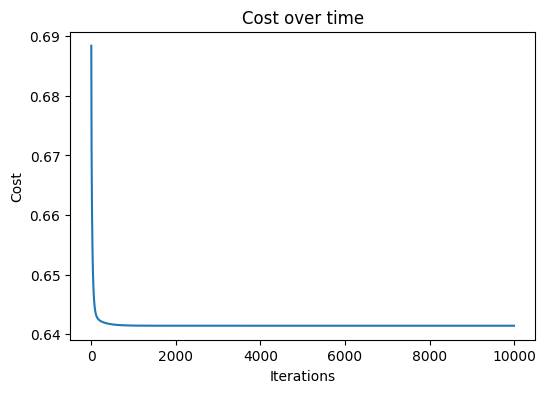

In [66]:
# initialize parameters w and b to 0 before training
w_in = np.zeros(X_train_norm.shape[1])
b_in = 0

w, b = run_gradient_descent(X_train_norm.values, y_train.values.reshape(-1), w_in, b_in, compute_cost,
                            compute_gradient, alpha=0.1, num_iters=10000, lambda_=0)

The learning curve shows a healthy exponential decrease in cost over number of iterations.

It seems like a global minimum is reached between iterations 1000 and 2000.

In [67]:
f_wb, p = predict(X_train_norm, w, b)
print(f"Accuracy on training set: {np.mean(p==y_train['signal'].values) * 100:.2f}%")

X_test_norm = apply_zscore_normalization(X_test, X_train_mu, X_train_sigma, columns=features)
f_wb2, p2 = predict(X_test_norm, w, b)
print(f"Accuracy on test set: {np.mean(p2==y_test['signal'].values) * 100:.2f}%")

Accuracy on training set: 61.73%
Accuracy on test set: 54.17%


A quick evaluation of our classification model shows a 61.73% training accuracy which is not bad for an elementary model and by only using 2 primary sources of information - price and volume.

Accuracy on the test set however dropped slightly which is expected but shows moderate generalization at 54.17%.

Evaluating classification models however require slighly more metrics which will be covered in more depth in the next notebook.

#### Comparing manual implementation with Scikit-learn's implementation

In [68]:
# comparing it with the logistic regression model from scikit-learn

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(penalty=None, solver='lbfgs', max_iter=10000)

model.fit(X_train_norm, y_train['signal'])

w_sklearn = model.coef_
b_sklearn = model.intercept_

y_hat = model.predict(X_train_norm)
print(f"Accuracy on training set: {model.score(X_train_norm, y_train['signal']) * 100:0.2f}%")

y_hat2 = model.predict(X_test_norm)
print(f"Accuracy on test set: {model.score(X_test_norm, y_test['signal']) * 100:0.2f}%")

Accuracy on training set: 61.73%
Accuracy on test set: 54.17%


c:\Users\DELL\Workspace\project_01_v2\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


The result of Scikit-learn's implementation is exactly the same as ours.

In [69]:
print(f"w_manual  : {w}, b_manual: {b:0.4f}"
      f"\nw_sklearn : {w_sklearn.flatten()}, b_sklearn: {b_sklearn[0]:0.4f}")

w_manual  : [ 0.459  -0.3079 -0.1972 -0.0719  0.2519 -0.0253], b_manual: -0.4251
w_sklearn : [ 0.459  -0.3079 -0.1973 -0.072   0.2517 -0.0252], b_sklearn: -0.4253


The learned parameters of the model - weights and bias - are nearly identical, which shows two things:
1. The numpy implementation of the cost function for logistic regression and the learning algorithm - gradient descent - were implemented correctly as intended.
2. It confirms that there is a global minimum for our cost function (not mathematically proven here), which also supports our initial assumption that the cost function is indeed convex.

In [70]:
# save the binary prediction of linear logistic regression for the X test set 
np.savetxt("../data/linear/pred.csv", p2)

## 3 Polynomial logistic regression

The same process is repeated for polynomial logistic regression.

#### Training a polynomial regression model

In [71]:
X_poly_train = pd.read_csv("../data/poly/X_poly_train.csv", index_col=0, parse_dates=True)
y_poly_train = pd.read_csv("../data/poly/y_poly_train.csv", index_col=0, parse_dates=True)
X_poly_test = pd.read_csv("../data/poly/X_poly_test.csv", index_col=0, parse_dates=True)
y_poly_test = pd.read_csv("../data/poly/y_poly_test.csv", index_col=0, parse_dates=True)

print(f"Shape\n"
      f"X_poly_train: {X_poly_train.shape}, y_poly_train: {y_poly_train.shape}\n"
      f"X_poly_test:  {X_poly_test.shape}, y_poly_test : {y_poly_test.shape}\n")

X_poly_train.head()

Shape
X_poly_train: (562, 27), y_poly_train: (562, 1)
X_poly_test:  (144, 27), y_poly_test : (144, 1)



,volume,pct_change_1d,rsi,adx,corr,volatility,volume^2,pct_change_1d^2,rsi^2,adx^2,...,pct_change_1d*rsi,pct_change_1d*adx,pct_change_1d*corr,pct_change_1d*volatility,rsi*adx,rsi*corr,rsi*volatility,adx*corr,adx*volatility,corr*volatility
Date,,,,,,,,,,,,,,,,,,,,,
2023-02-02,8523200,-0.0263,25.7175,20.0382,0.6622,1.5033,72644938240000,0.0007,661.3887,401.5287,...,-0.6768,-0.5273,-0.0174,-0.0396,515.3315,17.0313,38.6607,13.2702,30.1231,0.9955
2023-02-03,9219400,0.0270,39.1584,23.3034,0.7018,1.8069,84997336360000,0.0007,1533.3808,543.0485,...,1.0583,0.6298,0.0190,0.0488,912.5240,27.4803,70.7540,16.3537,42.1061,1.2680
2023-02-07,11662300,-0.0368,30.5575,27.4842,0.8373,2.0947,136009241290000,0.0014,933.7604,755.3826,...,-1.1258,-1.0126,-0.0308,-0.0772,839.8490,25.5844,64.0078,23.0113,57.5703,1.7538
2023-02-08,5665300,0.0109,35.0839,31.2470,0.8722,2.1606,32095624090000,0.0001,1230.8832,976.3729,...,0.3834,0.3415,0.0095,0.0236,1096.2669,30.6019,75.8037,27.2551,67.5134,1.8846
2023-02-09,6074700,0.0054,37.3526,33.7872,0.8379,2.1827,36901980090000,0.0000,1395.2168,1141.5725,...,0.2019,0.1826,0.0045,0.0118,1262.0385,31.2961,81.5298,28.3088,73.7475,1.8288


In [72]:
exclude = ['corr', 'volatility', 'corr^2', 'pct_change_1d*volatility']
cols_to_scale = [c for c in X_poly_train.columns if c not in exclude]

X_poly_train_norm, X_poly_train_mu, X_poly_train_sigma = zscore_normalize_features(X_poly_train, columns=cols_to_scale)

Iteration    0: Cost  0.68480
Iteration 5000: Cost  0.63055
Iteration 10000: Cost  0.63002
Iteration 15000: Cost  0.62976
Iteration 20000: Cost  0.62958
Iteration 25000: Cost  0.62946
Iteration 30000: Cost  0.62937
Iteration 35000: Cost  0.62930
Iteration 40000: Cost  0.62925
Iteration 45000: Cost  0.62921
Iteration 49999: Cost  0.62917


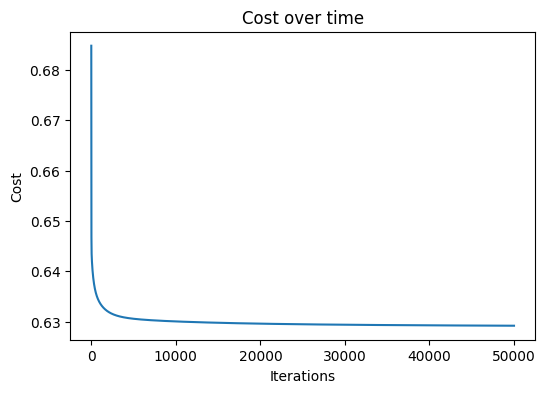

Accuracy on training set: 64.06%
Accuracy on test set: 50.69%


In [73]:
w2_in = np.zeros(X_poly_train_norm.shape[1])
b2_in = 0

w2, b2 = run_gradient_descent(X_poly_train_norm.values, y_poly_train['signal'].values, w2_in, b2_in, compute_cost,
                                            compute_gradient, alpha=0.1, num_iters=50000, lambda_=0) # no regularization

f_wb3, p3 = predict(X_poly_train_norm, w2, b2)
print(f"Accuracy on training set: {np.mean(p3==y_poly_train['signal'].values) * 100:0.2f}%")

X_poly_test_norm = apply_zscore_normalization(X_poly_test, X_poly_train_mu, X_poly_train_sigma, cols_to_scale)
f_wb4, p4 = predict(X_poly_test_norm, w2, b2)
print(f"Accuracy on test set: {np.mean(p4 == y_poly_test['signal'].values) * 100:0.2f}%")

Training accuracy for polynomial logistic regression is higher at 64.06% compared with 61.73% for the linear model. However, Testing accuracy dropped from 54.17% to 50.69%.

Both results can be explained by the tighter fit of polynomial features to the training set, which increases training accuracy but might cause higher overfitting and less generalizability to new data. This is especially true without any regularization.

In [75]:
# Scikit-learn implementation
model = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)

model.fit(X_poly_train_norm, y_poly_train['signal'])

w_sklearn = model.coef_      
b_sklearn = model.intercept_ 

y_hat3 = model.predict(X_poly_train_norm)
print(f"Accuracy on training set: {model.score(X_poly_train_norm, y_poly_train['signal']) * 100:0.2f}%")
y_hat4 = model.predict(X_poly_test_norm)
print(f"Accuracy on test set: {model.score(X_poly_test_norm, y_poly_test['signal']) * 100:0.2f}%")

Accuracy on training set: 63.88%
Accuracy on test set: 52.08%


c:\Users\DELL\Workspace\project_01_v2\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [76]:
print(f"w_manual: {w2}, b_manual: {b2:0.4f}"
      f"\nw_sklearn:\n{w_sklearn}, b_sklearn: {b_sklearn}\n")

w_manual: [ 0.085  -0.5934 -0.7115  0.2004  0.8127  0.7431  0.0484 -0.0734  0.6231
  0.8026  0.2995  0.1444  0.1417  0.269  -0.1502  0.4038  0.1078 -0.021
  0.1072  0.0656  0.9185 -0.4275 -0.2574  0.0477 -0.3601 -1.1496 -0.1371], b_manual: -2.2080
w_sklearn:
[[ 0.0137 -0.8586 -0.4625  0.2098  0.8709  1.1715  0.063  -0.1038  0.4979
   0.7814  0.3184  0.001   0.0803  0.3486 -0.1308  0.3903  0.0903  0.0679
   0.0374  0.0584  8.2278 -0.437  -0.2678 -0.1881 -0.3615 -1.1333 -0.1342]], b_sklearn: [-3.0594]



The learned parameters from the manual and scikit-learn implementation of polynomial logistic regression are not as identical as linear logistic regression.

The closest thing I could find to a classic batch gradient descent solver in Scikit-learn was 'lbfgs'. 'lbfgs' uses 2nd order derivative instead of just the slope, its step size is also dynamic instead of a fixed learning rate $\alpha$, the number of iterations also stop based on a certain tolerance instead of a fixed number.

The reasons above might explain the difference in the model parameters for a more complex feature set with many features.

In [77]:
# save the binary prediction of polynomial logistic regression for the test set 
np.savetxt("../data/poly/pred2.csv", p4)